In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("medical_examination.csv")

In [4]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df.columns

Index(['id', 'age', 'sex', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   sex          70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349843,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.477253,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,3.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### creating BMI column

In [8]:
bmi = df["weight"]/(df["height"]/100)**2

In [9]:
df["overweight"] = np.where(bmi > 25, 1, 0)

In [10]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


### normalizing the cholestrerol & gluc columns into two unique values

In [11]:
df["cholesterol"] = np.where(df["cholesterol"] == 1, 0, 1)
df["gluc"] = np.where(df["gluc"] == 1, 0, 1)

#### verifying the result

In [12]:
df["gluc"].unique()

array([0, 1])

In [13]:
df["cholesterol"].value_counts()

cholesterol
0    52385
1    17615
Name: count, dtype: int64

### creating category map

In [15]:
df_cat = pd.melt(
    df,
id_vars=["cardio"],
value_vars=["cholesterol","gluc", "smoke", "alco", "active", "overweight"])

In [17]:
df_cat.head(10)

,cardio,variable,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
5,0,cholesterol,1
6,0,cholesterol,1
7,1,cholesterol,1
8,0,cholesterol,0
9,0,cholesterol,0


In [18]:
df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 420000 entries, 0 to 419999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   cardio    420000 non-null  int64
 1   variable  420000 non-null  str  
 2   value     420000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 9.6 MB


In [27]:
df_cat.groupby(["cardio", "variable", "value"]).size()

cardio  variable     value
0       active       0         6378
                     1        28643
        alco         0        33080
                     1         1941
        cholesterol  0        29330
                     1         5691
        gluc         0        30894
                     1         4127
        overweight   0        15915
                     1        19106
        smoke        0        31781
                     1         3240
1       active       0         7361
                     1        27618
        alco         0        33156
                     1         1823
        cholesterol  0        23055
                     1        11924
        gluc         0        28585
                     1         6394
        overweight   0        10539
                     1        24440
        smoke        0        32050
                     1         2929
dtype: int64

In [26]:
df_cat.groupby(["cardio", "variable", "value"]).size().reset_index()

,cardio,variable,value,0
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


changing the column name to be cleaner

In [30]:
df_cat.groupby(["cardio", "variable", "value"]).size().reset_index(name="count")

,cardio,variable,value,count
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


now assigning all that to df_cat, (otherwise none of this will be actually saved to the original df_cat dataframe)

In [31]:
df_cat = df_cat.groupby(["cardio", "variable", "value"]).size().reset_index(name="count")

In [35]:
df_cat

,cardio,variable,value,count
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


### creating categroy plot

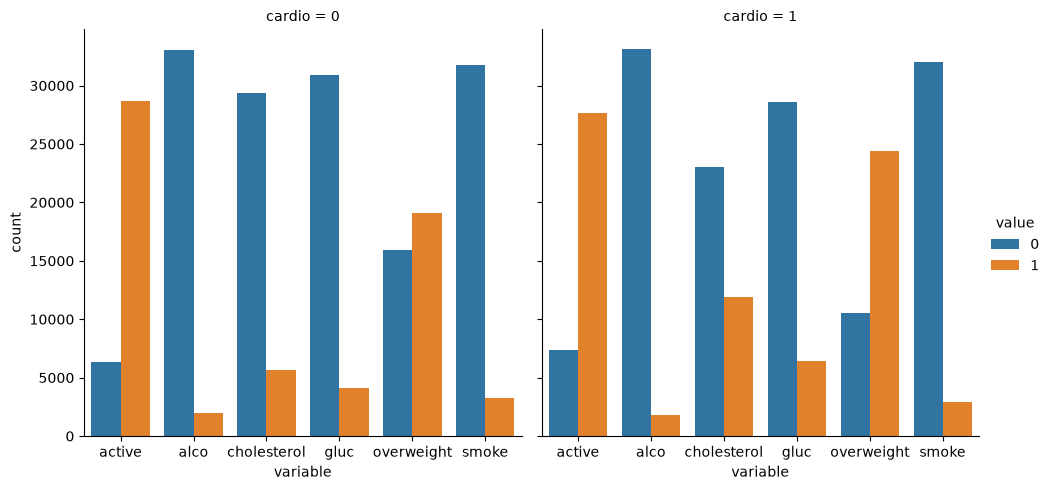

In [41]:
cat_plot = sns.catplot(
    data = df_cat,
    x = "variable",
    y = "count",
    hue = "value",
    col = "cardio",
    kind = "bar"
)

sns.catplot() returns a FacetGrid, not a Matplotlib Figure, thus we need to turn it into matplotlib figure

In [42]:
fig = cat_plot.fig

In [43]:
fig.savefig("catplot.png")

### creating heatmap

First, we need to clean the data:

1. Remove rows where the diastolic pressure is higher than the systolic pressure.
   - Keep rows where `df['ap_lo'] <= df['ap_hi']`.

2. Remove rows where the height is below the 2.5th percentile.
   - Keep rows where `df['height'] >= df['height'].quantile(0.025)`.

3. Remove rows where the height is above the 97.5th percentile.

4. Remove rows where the weight is below the 2.5th percentile.

5. Remove rows where the weight is above the 97.5th percentile.

Imagine this line:

|---2.5%---|------------95%------------|---2.5%---|

We throw away the two tiny ends because they often contain:

- measurement errors
- impossible values
- extreme outliers

and keep the middle 95% of the data.

Thus we ignore the most extreme 2.5% on each end so the correlation isn't distorted.

In [47]:
df_heat = df[
    (df["ap_lo"] <= df["ap_hi"])&
    (df["height"] <= df["height"].quantile(0.975))&
    (df["height"] >= df["height"].quantile(0.025))&
    (df["weight"] <= df["weight"].quantile(0.975))&
    (df["weight"] >= df["weight"].quantile(0.025))
]

now creating correlation matrix

In [48]:
corr = df_heat.corr()

creating the mask to hide upper triangle of the matrix (the matrix is mirrored so half of it is redundant)

In [49]:
mask = np.triu(np.ones_like(corr, dtype=bool))

#### creating the matplotlib figure

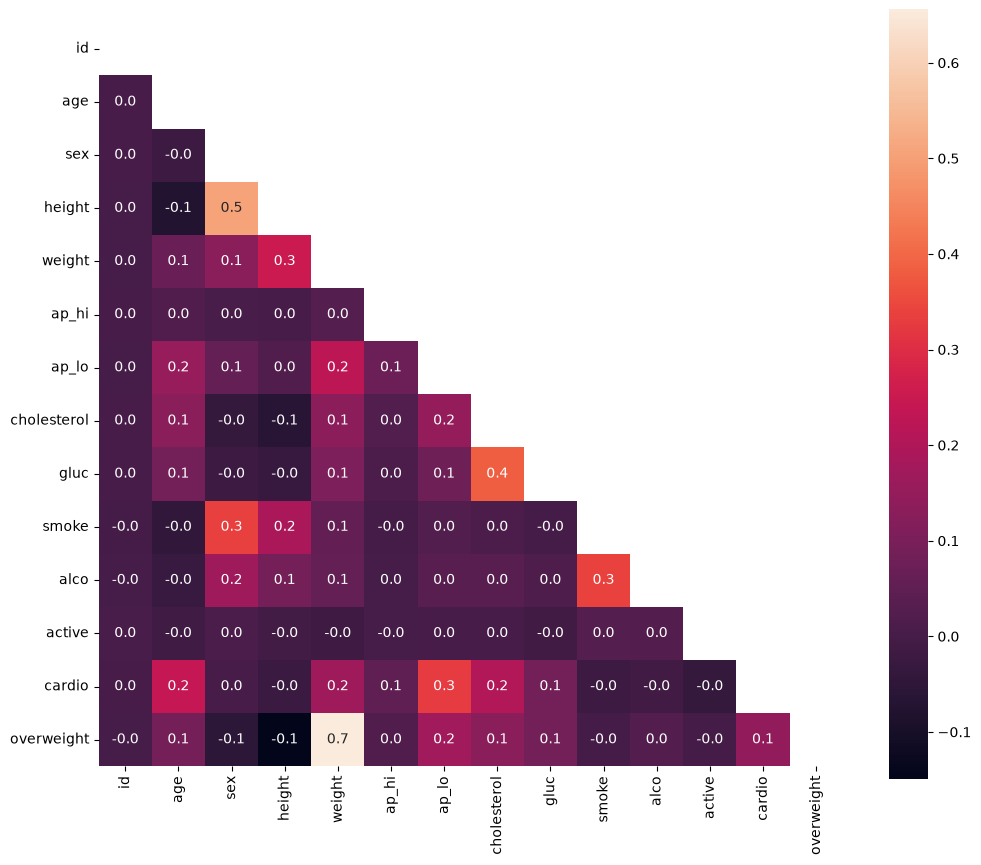

In [59]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr,
    mask = mask,
    annot = True,
    fmt = ".1f",
    square = True,
    ax=ax
    
)
plt.show()

In [61]:
fig.savefig("heatmap.png")

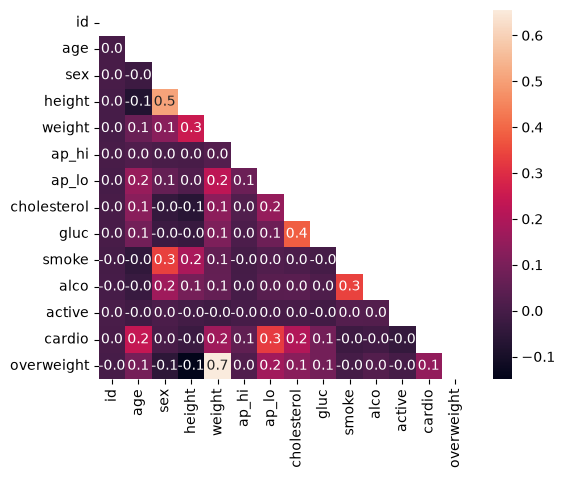

In [60]:
sns.heatmap(
    corr,
    mask = mask,
    annot = True,
    fmt = ".1f",
    square = True,
    
)
plt.show()

it seemed smaller because of the default size of the figuer as we didn't specifiy the fig or axis like in the previous case